### Sequential workflow using LLM 

In [1]:
from langgraph.graph import StateGraph,START,END
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from typing import TypedDict

In [2]:
load_dotenv()

True

In [3]:
model = ChatOpenAI()

In [4]:
# create state 
class LLMState(TypedDict):
    question:str
    answer:str

In [5]:
# ask the question to LLM 
def llm_qa(state: LLMState) -> LLMState:

    #extract the question from state
    question = state["question"]

    # form aprompt 
    prompt = f"Answer the following question {question}"

    # ask that question to model 
    answer = model.invoke(prompt).content

    # update the state 
    state["answer"] = answer

    return state 

In [6]:
# create the graph 
graph =  StateGraph(LLMState)

# add the node 
graph.add_node("llm_qa",llm_qa)

# add edges 
graph.add_edge(START,"llm_qa")
graph.add_edge("llm_qa",END)

# compile the graph 
workflow = graph.compile()

In [7]:
# execute the graph 
initial_state = {"question":"How far is moon from the Earth ?"}

final_state = workflow.invoke(initial_state)
print(final_state["answer"])

The average distance between the Earth and the Moon is about 384,400 kilometers (238,855 miles).


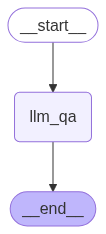

In [8]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())